<a href="https://colab.research.google.com/github/haleshgowda77/FUTURE_DS_01/blob/main/Task01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

In [5]:
! unzip online_retail.csv.zip

Archive:  /online_retail.csv.zip
replace online_retail.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
import pandas as pd

In [6]:
df=pd.read_csv('/online_retail.csv.zip')


In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df = df.dropna(subset=['CustomerID'])
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [11]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [13]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df_indexed = df.set_index('InvoiceDate')
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print("Total Revenue:", df['Revenue'].sum())
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())

Total Revenue: 8300065.814000001
Total Orders: 22190
Total Customers: 4372


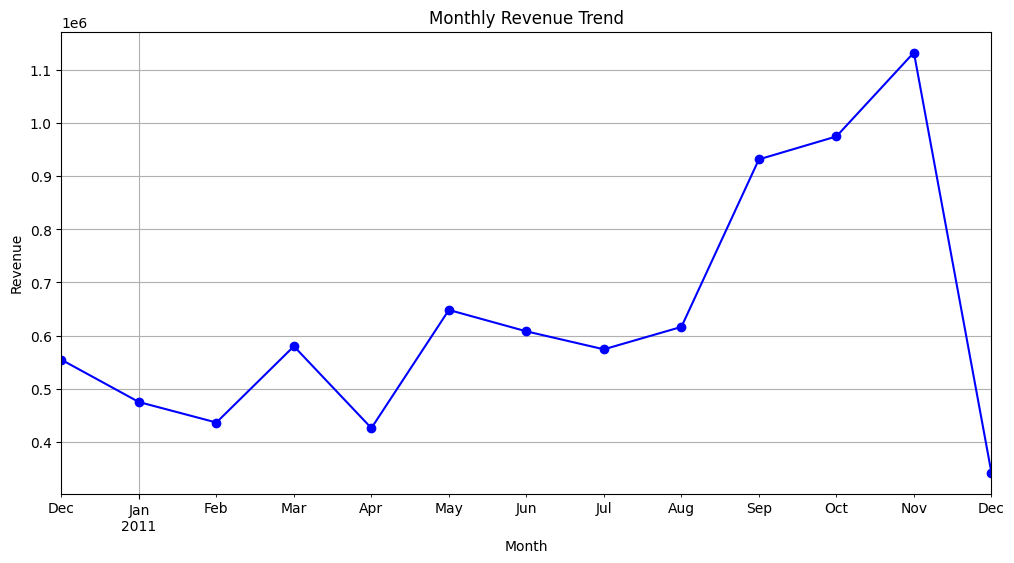

In [15]:
monthly_revenue = df_indexed['Revenue'].resample('ME').sum()


# Plot
monthly_revenue.plot(figsize=(12,6), marker='o', color='blue')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.savefig('Monthly Revenue Trend')
plt.show()

In [16]:
from google.colab import files
files.download("Monthly Revenue Trend.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

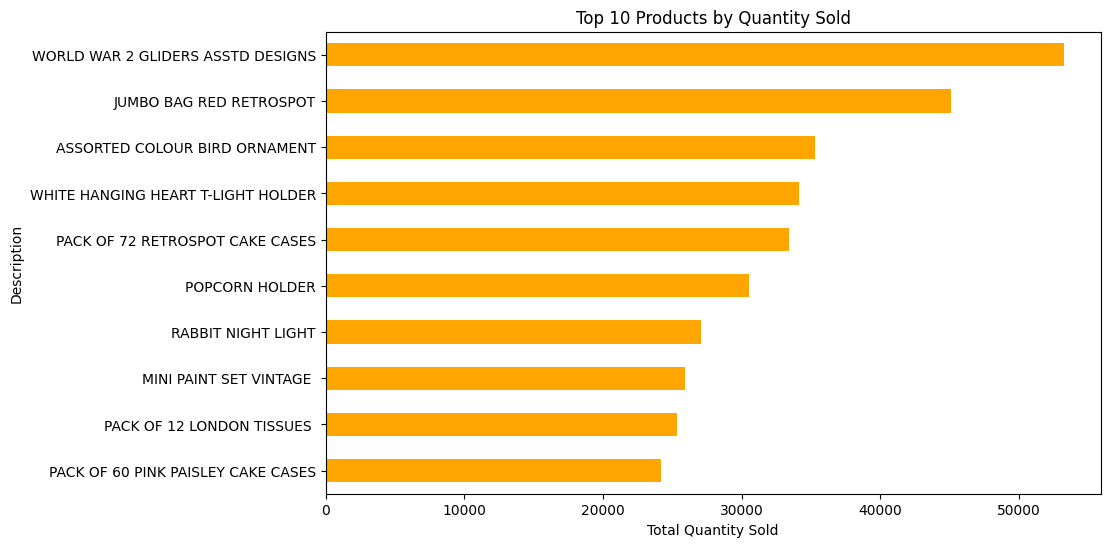

In [17]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(10,6), color='orange')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.gca().invert_yaxis()
plt.savefig('Top 10 Products by Quantity Sold')
plt.show()


In [18]:
from google.colab import files
files.download("Top 10 Products by Quantity Sold.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

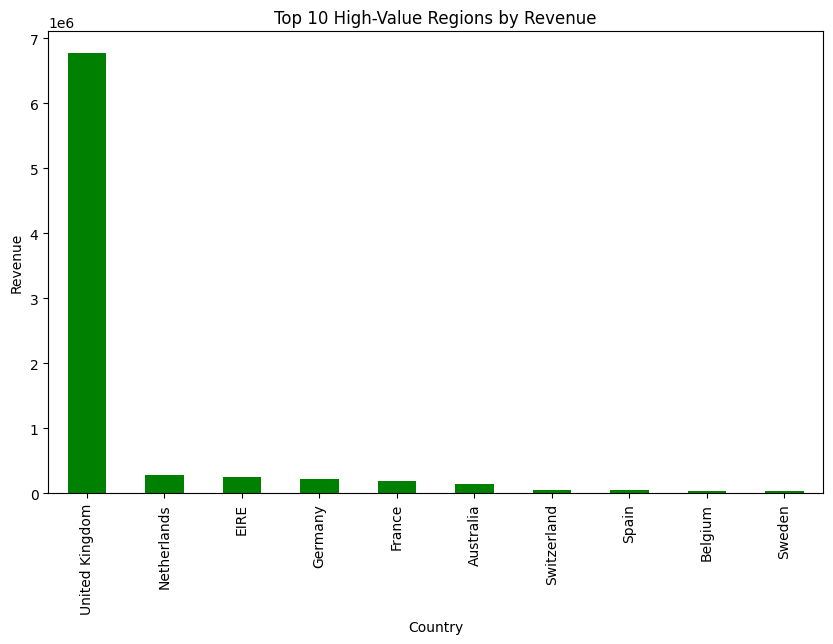

In [19]:
rev_by_region = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

rev_by_region.plot(kind='bar', figsize=(10,6), color='green')
plt.title("Top 10 High-Value Regions by Revenue")
plt.ylabel("Revenue")
plt.savefig('Top 10 High-Value Regions by Revenue')
plt.show()

In [20]:
from google.colab import files
files.download("Top 10 High-Value Regions by Revenue.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>